In [6]:
import sys
sys.path.append("../src")
from pprint import pprint
from pathlib import Path
import numpy as np

# Analysis of confidence scores for each category

Categories classification confidence : The confidence seems to be variable. We need to explore repetitions of the same dataset to see if the confidence is consistent.
  * [ ] Explore confidence variability
  * [ ] Sample 10 datasets and generate 30 classifications for each dataset
  * [ ] For all categories, plot the distribution of confidence
  * [ ] See if this distribution is consistent across datasets
  * [ ] See if this distribution is consistent across ranges of confidence

In [18]:
# Load datasets from dryad

from dryad_api import search_datasets
import pickle
from pathlib import Path

datasets_pickle = "data/datasets.pickle"

if Path(datasets_pickle).exists():
    with open(datasets_pickle, "rb") as f:
        datasets = pickle.load(f)
else:
    datasets = search_datasets(["quebec ecology"], per_page=100)
    with open(datasets_pickle, "wb") as f:
        pickle.dump(datasets, f)

In [19]:
from gpt_classify import classify_abstract
from dotenv import load_dotenv
from pathlib import Path
import pickle
import pandas as pd

# Running the classification on 10 first abstracts, 10 times each

N_ABSTRACTS = 10
N_RUNS = 20

load_dotenv()

def assert_categories(classification):
    try:
        assert isinstance(classification, dict)
        assert "categories" in classification
        categories = classification["categories"]
        assert isinstance(categories, dict)
        # Assert length
        assert len(categories) > 0
        # Assert values
        for category, confidence in categories.items():
            assert isinstance(category, str)
            assert isinstance(confidence, float)
            assert confidence >= 0 and confidence <= 1
        return True
    except AssertionError:
        return False

def run_classification(doi, abstract, n_runs=N_RUNS):
    out = {
        "doi": doi,
        "abstract": abstract,
        "classification": None,
        "failed_attempts": 0
    }
    max_tries = 5
    while out["failed_attempts"] < max_tries and not out["classification"]:
        classification = classify_abstract(abstract)
        valid_categories = assert_categories(classification)
        if classification and valid_categories:
            out["classification"] = classification
        else:
            out["failed_attempts"] += 1
    return out

pickle_path = "data/category_analysis_classification_gpt4_temp0.pickle"

if Path(pickle_path).exists():
    with open(pickle_path, "rb") as f:
        classification_results = pickle.load(f)
else:
    classification_results = []



In [20]:
len(classification_results)

200

## Post processing the categories classification


In [23]:
list(classification_results[0]['classification']['response']['categories'].items())

[('abundances', 0.9), ('presence/absence', 0.8), ('trait data', 0.7)]

In [24]:
import pandas as pd

# Storing results in a datasets for further analysis
columns = ['doi', 'category', 'score']

df = pd.DataFrame(columns = columns)

# Limit to first 10 results per abstract

# Sort by doi
classification_results = sorted(classification_results, key=lambda x: x['doi'])

# Iterate over results, break when 10 results for a 
MAX_DOI = N_RUNS

doi_counts = {}
for result in classification_results:
    doi = result['doi']
    try:
        doi_counts[doi] += 1
    except KeyError:
        doi_counts[doi] = 1
    if doi_counts[doi] > MAX_DOI:
        continue
    for category, score in result['classification']['response']['categories'].items():
        df.loc[len(df)] = [doi, category, score]

# for result in classification_results:
#     for category, score in result['classification']['response']['categories'].items():
#         df.loc[len(df)] = [result['doi'], category, score]

print(df.head())
sorted(df['category'].unique())

                           doi          category  score
0  doi:10.5061/dryad.000000022        abundances    0.9
1  doi:10.5061/dryad.000000022  presence/absence    0.8
2  doi:10.5061/dryad.000000022        trait data    0.7
3  doi:10.5061/dryad.000000022        abundances    0.9
4  doi:10.5061/dryad.000000022        trait data    0.8


['abundances',
 'plots',
 'population time-series',
 'presence/absence',
 'trait data']

Highly variable category naming (plurals, capitalization, punctuation, etc.). We create a function to clean that.

Even though we supply a specific list of categories to the GPT-3 model, it will sometimes return categories that are not in the list. We will try to clean these categories to match the ones in the list.

### Are the scores provided by chat gpt-4 consistent or are they random?

I need to decide if I trust the classification scores. I trust them if they answer to two condifitions
- Is the classification high enough?
- Is the score from a deterministic process? (non-random)

In [49]:
classification_results[0]['classification']['response']['regions_of_interest']

# All doi, regions of interest
roi_df = pd.DataFrame(columns=['doi', 'region', 'score'])
for result in classification_results:
    regions = result['classification']['response']['regions_of_interest']
    doi = result['doi']
    for region in regions:
        roi_df.loc[len(roi_df)] = [doi, region, 1]

# Group by doi and region
roi_df = roi_df.groupby(['doi', 'region']).sum().reset_index()

In [51]:
roi_df.groupby(['doi', 'region']).count().reset_index()

,doi,region,score
0,doi:10.5061/dryad.000000022,Dimictic lakes,1
1,doi:10.5061/dryad.000000022,dimictic lakes,1
2,doi:10.5061/dryad.4767v,"Boreal Forest of Quebec, Canada",1
3,doi:10.5061/dryad.4767v,"Boreal forest of Quebec, Canada",1
4,doi:10.5061/dryad.5ff8m0q,Malbaie,1
5,doi:10.5061/dryad.5ff8m0q,Malbaie River,1
6,doi:10.5061/dryad.5ff8m0q,"Malbaie River, Quebec, Canada",1
7,doi:10.5061/dryad.5ff8m0q,Province of Quebec,1
8,doi:10.5061/dryad.5ff8m0q,"Quebec, Canada",1
9,doi:10.5061/dryad.5ff8m0q,Rimouski,1


In [38]:
# df groupby mean 'score' by 'category'
df.groupby(['doi','category']).agg({'score': ['min', 'mean', 'max', 'std'], 'category': 'count'})


score                 \
                                                     min      mean  max   
doi                         category                                      
doi:10.5061/dryad.000000022 abundances               0.9  0.900000  0.9   
                            population time-series   0.7  0.700000  0.7   
                            presence/absence         0.8  0.800000  0.8   
                            trait data               0.7  0.760000  0.8   
doi:10.5061/dryad.4767v     abundances               0.8  0.905000  1.0   
                            plots                    0.7  0.795000  0.9   
                            trait data               0.7  0.775000  0.9   
doi:10.5061/dryad.5ff8m0q   population time-series   0.8  0.800000  0.8   
                            trait data               0.9  0.900000  0.9   
doi:10.5061/dryad.63fr7     abundances               0.7  0.700000  0.7   
                            population time-series   0.7  0.792857  0.8   
                            trait data               0.9  0.900000  0.9   
doi:10.5061/dryad.6vk6f     abundances               0.6  0.677778  0.7   
                            population time-series   0.7  0.700000  0.7   
                            trait data               0.9  0.900000  0.9   
doi:10.5061/dryad.7tn01     abundances               0.7  0.780000  0.8   
                            trait data               0.9  0.995000  1.0   
doi:10.5061/dryad.8281      abundances               0.7  0.700000  0.7   
                            population time-series   0.9  0.900000  0.9   
                            trait data               0.8  0.800000  0.8   
doi:10.5061/dryad.np5hqbzvd population time-series   0.8  0.800000  0.8   
                            trait data               0.9  0.900000  0.9   
doi:10.5061/dryad.pg4f4qrs4 abundances               0.7  0.795000  0.8   
                            trait data               0.8  0.895000  0.9   
doi:10.5061/dryad.vs671     abundances               0.7  0.700000  0.7   
                            population time-series   0.8  0.880000  0.9   
                            trait data               0.8  0.820000  0.9   

                                                             category  
                                                         std    count  
doi                         category                                   
doi:10.5061/dryad.000000022 abundances              0.000000       20  
                            population time-series  0.000000       12  
                            presence/absence        0.000000        8  
                            trait data              0.050262       20  
doi:10.5061/dryad.4767v     abundances              0.068633       20  
                            plots                   0.075915       20  
                            trait data              0.078640       20  
doi:10.5061/dryad.5ff8m0q   population time-series  0.000000       20  
                            trait data              0.000000       20  
doi:10.5061/dryad.63fr7     abundances              0.000000        6  
                            population time-series  0.026726       14  
                            trait data              0.000000       20  
doi:10.5061/dryad.6vk6f     abundances              0.044096        9  
                            population time-series  0.000000       13  
                            trait data              0.000000       20  
doi:10.5061/dryad.7tn01     abundances              0.041039       20  
                            trait data              0.022361       20  
doi:10.5061/dryad.8281      abundances              0.000000        2  
                            population time-series  0.000000       20  
                            trait data              0.000000       20  
doi:10.5061/dryad.np5hqbzvd population time-series  0.000000       20  
                            trait data              0.000000       20  


c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


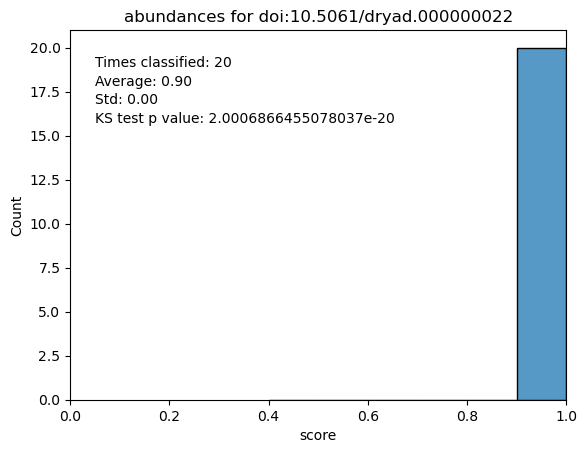

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


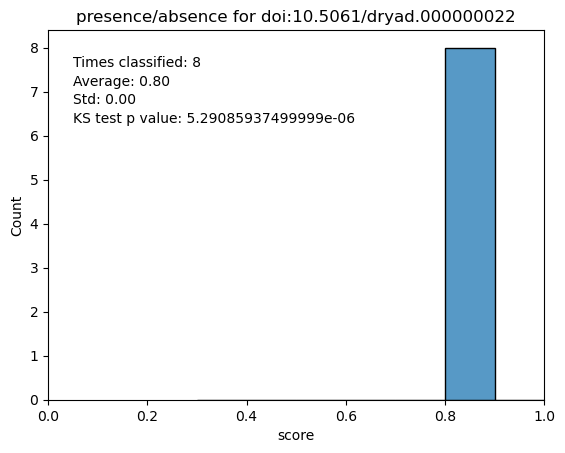

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


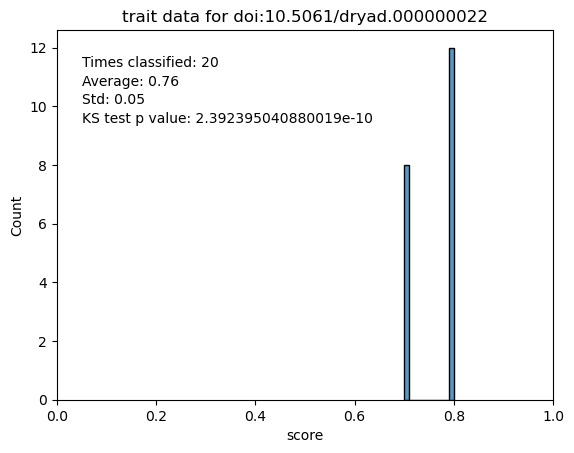

c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


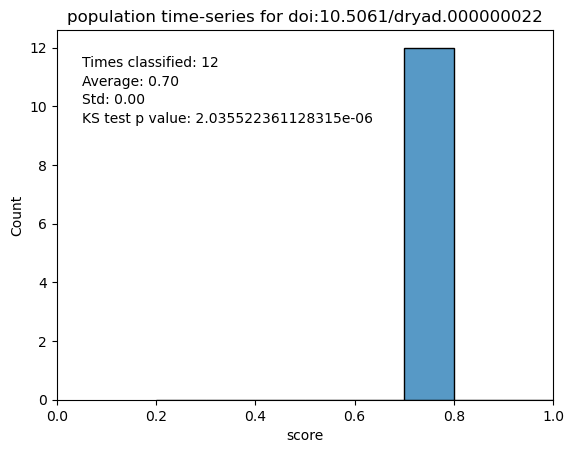

In [25]:
# For a single paper, show histograms of scores with colors by category
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest

doi = datasets[0]['identifier']

df_doi = df[df['doi'] == doi]

# Hists values for each category
for category in df_doi['category'].unique():
    df_category = df_doi[df_doi['category'] == category]
    sns.histplot(data=df_category, x="score", bins=10)
    plt.title(f"{category} for {doi}")
    plt.xlim(0, 1)
    # Show average and std as text in plot
    plt.text(0.05, 0.9, f"Times classified: {len(df_category)}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.85, f"Average: {df_category['score'].mean():.2f}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.8, f"Std: {df_category['score'].std():.2f}", transform=plt.gca().transAxes)

    # ks test
    ks_test = kstest(df_category['score'], 'uniform')
    pvalue = ks_test.pvalue
    plt.text(0.05, 0.75, f"KS test p value: {pvalue}", transform=plt.gca().transAxes)

    plt.show()


In [15]:
# For all doi and categories, and categories, compute average, std of scores and ks test p value

doi_cat_scores_columns = ['doi', 'category', 'hallucinated', 'n', 'average', 'std', 'ks_test_pvalue', 'ci_lower_95', 'ci_upper_95']

df_doi_cat_scores = pd.DataFrame(columns = doi_cat_scores_columns)

for doi in df['doi'].unique():
    df_doi = df[df['doi'] == doi]
    for category in df_doi['category'].unique():
        hallucinated = df_doi[df_doi['category'] == category]['hallucinated'].iloc[0]
        df_category = df_doi[df_doi['category'] == category]
        average = df_category['score'].mean()
        std = df_category['score'].std()
        ks_test = kstest(df_category['score'], 'uniform')
        pvalue = ks_test.pvalue
        # 95% confidence interval using t distribution
        n = len(df_category)
        t = 2.262 # t value for 95% confidence interval with n-1 degrees of freedom
        ci_lower = average - t * std / n**0.5
        ci_upper = average + t * std / n**0.5
        df_doi_cat_scores.loc[len(df_doi_cat_scores)] = [doi, category, hallucinated, n, average, std, pvalue, ci_lower, ci_upper]

df_doi_cat_scores.head(10)

,doi,category,hallucinated,n,average,std,ks_test_pvalue,ci_lower_95,ci_upper_95
0,doi:10.5061/dryad.000000022,abundances,False,20,0.900000,2.278130e-16,2.000687e-20,0.900000,0.900000
1,doi:10.5061/dryad.000000022,presence/absence,False,8,0.800000,0.000000e+00,5.290859e-06,0.800000,0.800000
2,doi:10.5061/dryad.000000022,trait data,False,20,0.760000,5.026247e-02,2.392395e-10,0.734577,0.785423
3,doi:10.5061/dryad.000000022,population time-series,False,12,0.700000,1.159590e-16,2.035522e-06,0.700000,0.700000
4,doi:10.5061/dryad.pg4f4qrs4,trait data,False,17,0.894118,2.425356e-02,5.492973e-14,0.880812,0.907424
5,doi:10.5061/dryad.pg4f4qrs4,abundances,False,17,0.794118,2.425356e-02,4.061874e-10,0.780812,0.807424


c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\beav3503\Miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.

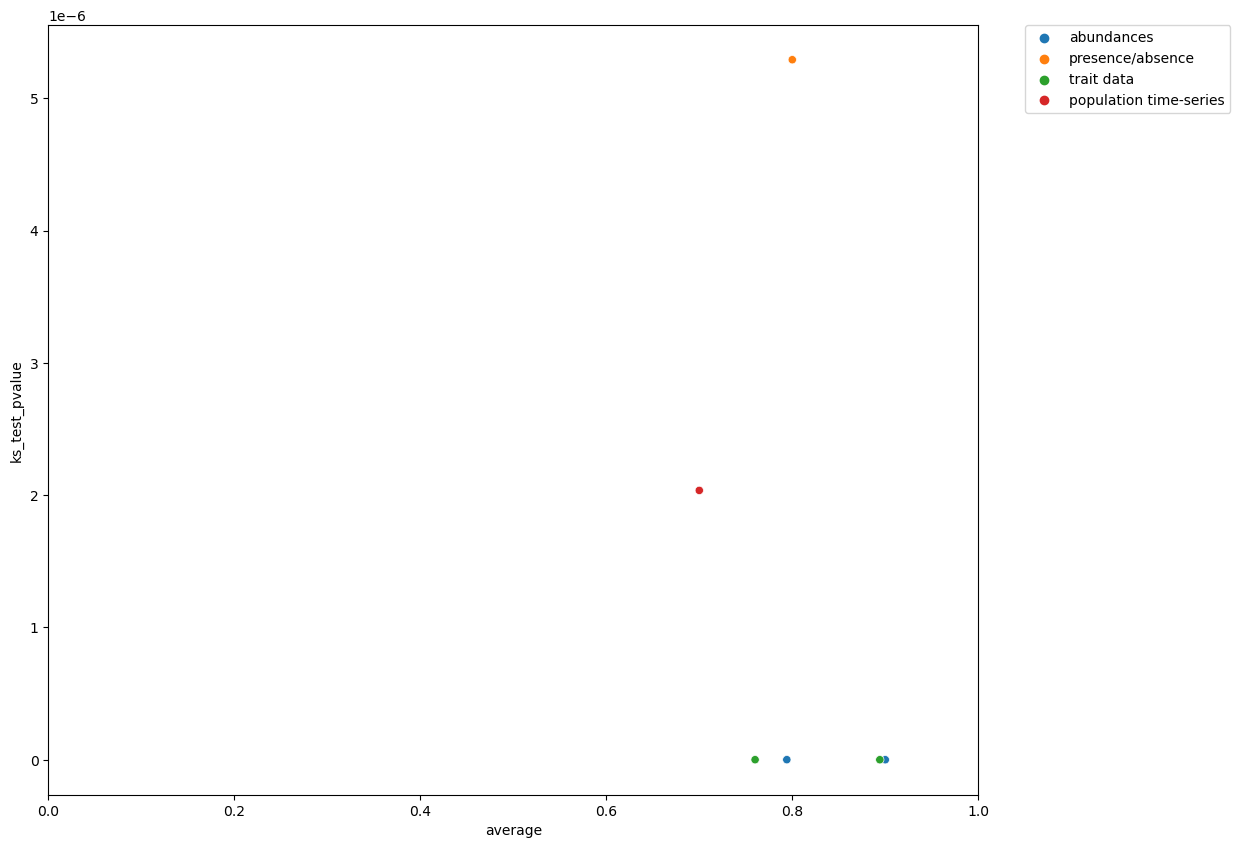

In [16]:
# Is there a correlation between the average score and the p value of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="ks_test_pvalue", color="black", marker="o", s=100)

# Use losange marker, and color by category
sns.scatterplot(data=df_doi_cat_scores, x="average", y="ks_test_pvalue", hue="category")


plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

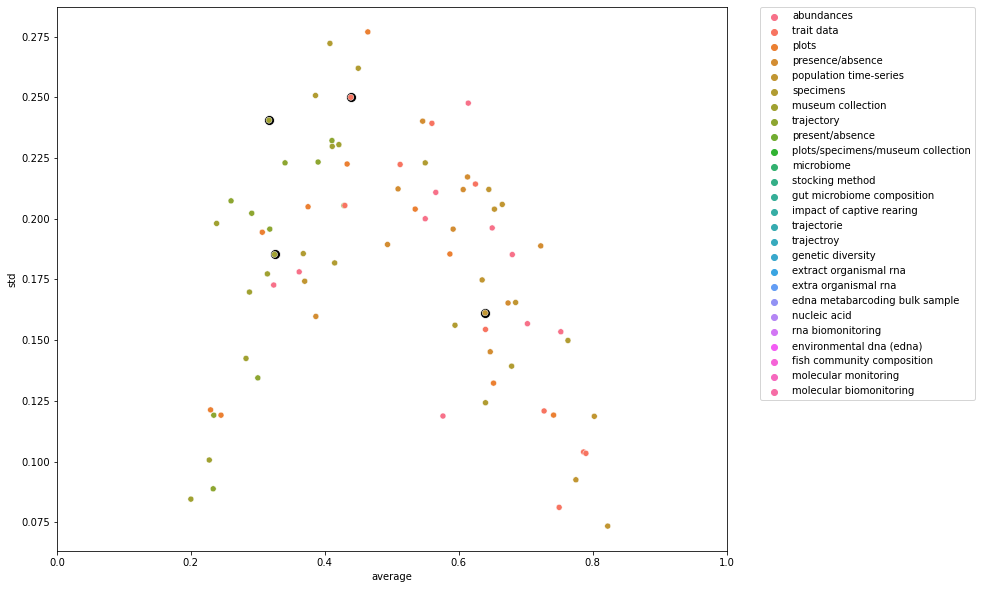

In [ ]:
# Is there a correlation between the average score and the std of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="std", color="black", marker="o", s=100)
sns.scatterplot(data=df_doi_cat_scores, x="average", y="std", hue="category")

plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

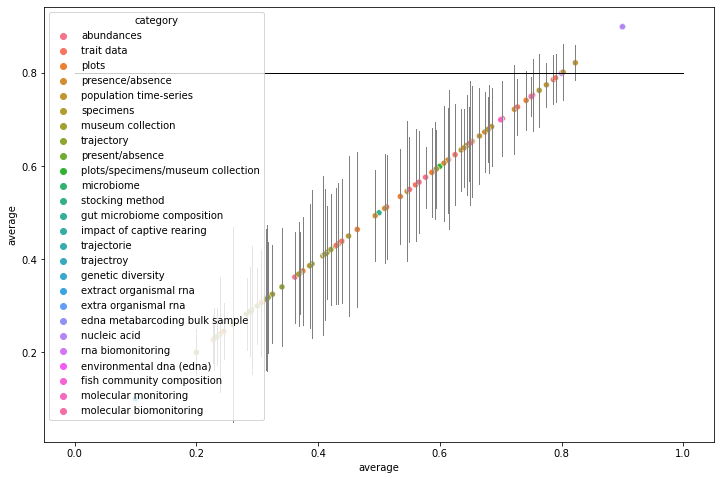

In [ ]:
# Plot vertical lines for 95% confidence interval starting at (average, ci_lower) and ending at (average, ci_upper)
plt.figure(figsize=(12, 8))
for i, row in df_doi_cat_scores.iterrows():
    plt.plot([row['average'], row['average']], [row['ci_lower_95'], row['ci_upper_95']], color='grey', linestyle='-', linewidth=1)
    # Scatter plot of average average

sns.scatterplot(data=df_doi_cat_scores, x="average", y="average", hue="category")

# Horizontal line at 0.8
plt.plot([0, 1], [0.8, 0.8], color='black', linestyle='-', linewidth=1)

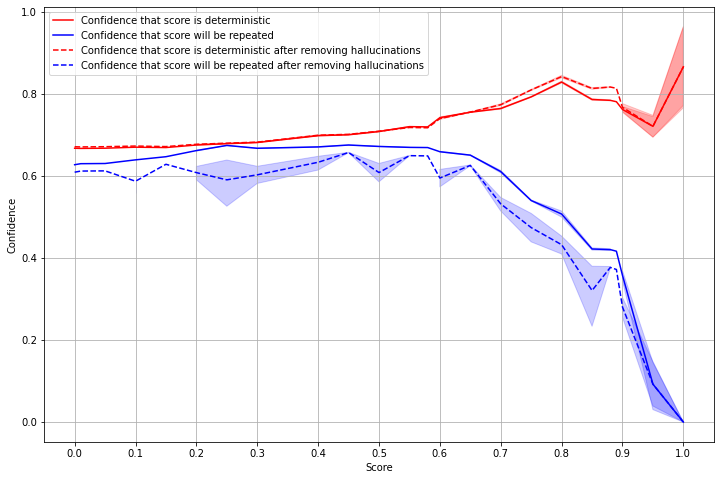

In [ ]:
# What is a good threshold to choose to make sure that the classification is from a non-uniform distribution which score is close to the average

KS_THRESHOLD = 0.05
DEV_THRESHOLD = 0.15

ks_threshold_column = "confidence_threshold_ks_{}".format(str(KS_THRESHOLD).replace(".", ""))
dev_threshold_column = "confidence_dev_{}".format(str(DEV_THRESHOLD).replace(".", ""))


# Add dist_ks_pvalue to df
df["dist_ks_pvalue"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "ks_test_pvalue"]], on=["doi", "category"], how="left")["ks_test_pvalue"]
df["dist_average"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "average"]], on=["doi", "category"], how="left")["average"]
df["deviation"] = abs(df["score"] - df["dist_average"])

# Cumulative confidence on df sorted by score
df = df.sort_values(by=["score"], ascending=False)
df.reset_index(inplace=True, drop=True)
df[f"{ks_threshold_column}"] = (df["dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{dev_threshold_column}"] = (df["deviation"] <= DEV_THRESHOLD).expanding().mean()

# Thresholds if excluding hallucinated categorie values

df.loc[df["hallucinated"] == False, f"{ks_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{ks_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)

df.loc[df["hallucinated"] == False, f"{dev_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "deviation"] <= DEV_THRESHOLD).expanding().mean()
df[f"{dev_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)


# Plot threshold curves with dashed lines for halluncinated categories and solid lines for non-hallucinated categories
# Plot blue for deviation and red for ks test
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}", color="red", linestyle='-', label = "Confidence that score is deterministic")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}", color="blue", linestyle='-', label = "Confidence that score will be repeated")
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}_no_hallucinated", color="red", linestyle='--', label = "Confidence that score is deterministic after removing hallucinations")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}_no_hallucinated", color="blue", linestyle='--', label = "Confidence that score will be repeated after removing hallucinations")

plt.xticks(np.arange(0, 1.1, 0.1)) #Every 0.1

# Add grid
plt.grid()

plt.xlabel("Score")
plt.ylabel("Confidence")

plt.show()


<Axes: xlabel='score', ylabel='deviation'>

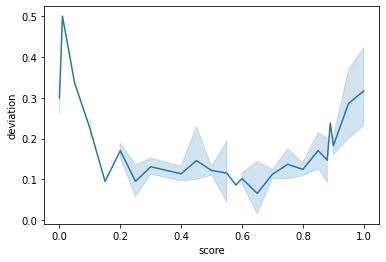

In [ ]:
sns.lineplot(data=df, x="score", y="deviation")


In [ ]:
# Sort by score and show the top 10
df.sort_values(by=['score'], ascending=False).head(20)

,doi,category,score,hallucinated,dist_ks_pvalue,dist_average,deviation,confidence_threshold_ks_005,confidence_dev_005,confidence_ks_005_no_hallucinated,confidence_dev_005_no_hallucinated
0,doi:10.5061/dryad.8281,specimens,1.00,False,7.196927e-06,0.763158,0.236842,1.000000,0.000000,1.000000,0.0
2,doi:10.5061/dryad.vs671,plots,1.00,False,6.996174e-01,0.464286,0.535714,0.333333,0.000000,0.333333,0.0
3,doi:10.5061/dryad.vs671,trait data,1.00,False,8.750049e-09,0.790000,0.210000,0.500000,0.000000,0.500000,0.0
4,doi:10.5061/dryad.vs671,population time-series,1.00,False,8.750049e-09,0.802500,0.197500,0.600000,0.000000,0.600000,0.0
5,doi:10.5061/dryad.000000022,presence/absence,1.00,False,3.787595e-05,0.722500,0.277500,0.666667,0.000000,0.666667,0.0
6,doi:10.5061/dryad.4767v,abundances,1.00,False,3.286197e-06,0.752500,0.247500,0.714286,0.000000,0.714286,0.0
7,doi:10.5061/dryad.000000022,presence/absence,1.00,False,3.787595e-05,0.722500,0.277500,0.750000,0.000000,0.750000,0.0
1,doi:10.5061/dryad.vs671,specimens,1.00,False,4.618105e-01,0.450000,0.550000,0.500000,0.000000,0.500000,0.0
12,doi:10.5061/dryad.4767v,population time-series,0.95,False,1.075496e-02,0.635000,0.315000,0.769231,0.000000,0.769231,0.0
13,doi:10.5061/dryad.4767v,trait data,0.95,False,3.527202e-01,0.512500,0.437500,0.714286,0.000000,0.714286,0.0


In [ ]:
## Question : Do halucinated classifications, presenting themselves as either typoed class names, or represents bad classification